In [46]:
### TensorFlow as tf
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 폰트 지정
plt.rc('font', family='Malgun Gothic')

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False


In [47]:
# 1. 데이터 준비
# x_data : 입력 데이터, y_data : 출력 데이터
x_data = np.array([1, 2, 3, 4, 5], dtype=np.float32)
y_data = np.array([1, 3, 5, 7, 9], dtype=np.float32)

In [48]:
# 2.모델 정의
# 가중치(w)와 편향(b)를 변수로 정의
w = tf.Variable(0.0)
b = tf.Variable(0.0)

In [49]:
# 예측 함수 ( y = wx + b )
def predict(x):
    return w * x + b

In [50]:
# 손실 함수 ( 평균 제곱 오차 )
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

In [51]:
# 3. 최적화 알고리즘 선택
optimizer = tf.optimizers.SGD(learning_rate=0.01) # 확률적 경사 하강법

In [52]:
# 4. 학습 과정
for step in range(100):
    with tf.GradientTape() as tape:
        y_pred = predict(x_data) # 예측값
        loss = loss_fn(y_data, y_pred) # 손실값 
    # 가중치와 편향에 대한 경사도 계산 및 업데이트
    gradients = tape.gradient(loss, [w, b]) # 가중치, 절편에 대해 미분 계산
    optimizer.apply_gradients(zip(gradients, [w, b])) # 가중치와 편향 업데이트

    if step % 10 == 0:
        print(f"Step {step}, w: {w.numpy()}, b: {b.numpy()}, loss: {loss.numpy()}")

Step 0, w: 0.3799999952316284, b: 0.09999999403953552, loss: 33.0
Step 10, w: 1.5327637195587158, b: 0.36772510409355164, loss: 0.5016436576843262
Step 20, w: 1.6221706867218018, b: 0.3426348865032196, loss: 0.33176523447036743
Step 30, w: 1.6397154331207275, b: 0.29930004477500916, loss: 0.30941861867904663
Step 40, w: 1.6520464420318604, b: 0.25612589716911316, loss: 0.28915175795555115


Step 50, w: 1.6636556386947632, b: 0.21430334448814392, loss: 0.2702149450778961
Step 60, w: 1.6748573780059814, b: 0.17386764287948608, loss: 0.2525184750556946
Step 70, w: 1.6856848001480103, b: 0.13477805256843567, loss: 0.235980823636055
Step 80, w: 1.6961513757705688, b: 0.09699011594057083, loss: 0.22052612900733948
Step 90, w: 1.706269383430481, b: 0.06046053394675255, loss: 0.20608380436897278


In [53]:
# 5. 예측 및 결과 확인
print("파이널 파라미터", f'w={w.numpy()}, b={b.numpy()}')
print("Prediction for x=5", predict(5).numpy())

파이널 파라미터 w=1.7150874137878418, b=0.028625113889575005
Prediction for x=5 8.604063


# Keras를 활용한 y = 2x +1 선형회귀 모델 예측 예제 

In [54]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [55]:
# 1. 데이터 준비
# 입력(x)과 출력(y)
x_data = np.array([1, 2, 3, 4, 5], dtype=np.float32) # 입력 데이터
y_data = np.array([1, 3, 5, 7, 9], dtype=np.float32) # 출력 데이터

In [56]:
# 2. 모델정의
# Sequential Api를 사용해 신경망 정의합니다.
model = Sequential([
    Dense(1, input_dim=1) # 입력 1개, 출력 1개 (선형 회귀)
])

d:\python_sim\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# 3. 모델 컴파일
# 손실 함수와 옵티마이저를 설정합니다.
model.compile(loss='mse', optimizer='sgd')

In [58]:
# 4. 모델 학습
# fit() 메서드로 데이터를 학습시킵니다.
model.fit(x_data, y_data, epochs=50, verbose=1) # 50번 반복 학습

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 45.3271
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 26.5870
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.6651
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.2992
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 5.5883
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 3.4246
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.1626
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.4260
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9957
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.7438
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5959
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5086
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4566
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4253
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4059
Epoch 16/50
1/1 ━━━━━━━━━━━━━━

In [59]:
# 5. 예측 및 평가
# 새로운 데이터로 예측 수행
x_new = np.array([5], dtype=np.float32)
y_new = model.predict(x_new)

print(f"예측값: {y_new[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
예측값: 8.51


# MINIST 예제 (CNN 모델 예제)

In [60]:
# 1. 필요한 라이브러리 임포트
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow as tf

In [61]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

In [62]:
# 2. 데이터 로드 및 전처리
# MNIST 데이터셋은 이미 나위어 제공 (학습/테스트 데이터)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [63]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [64]:
# MNIST 이미지는 28x28 크기, 채널 정보 추가 (흑백 이미지는 채널 1개, 컬러는 3개)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255.0
x_train.shape

(60000, 28, 28, 1)

In [65]:
# 레이블을 One-Hot 인코딩 (숫자 0~9를 벡터로 변환) ex. 0 => [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# One-Hot 인코딩 : 범주형 데이터를 수치형 데이터로 변환하는 방법
if len(y_train.shape) == 1: # shape이 1차원 즉, (n,) 인지 확인
    y_train = tf.keras.utils.to_categorical(y_train, 10) # to_categorical (원핫 인코딩 대상, 클래스 갯수)
if len(y_test.shape) == 1: # shape이 1차원 즉 (n,) 인지 확인
    y_test = tf.keras.utils.to_categorical(y_test, 10) # to_categorical (원핫 인코딩 대상, 클래스 갯수)
    

In [66]:
# 3. CNN 모델 정의
model = models.Sequential() # 순차적 모델 선언

In [67]:
# 첫 번째 합성곱 계층 : 필터 크기 3x3, 필터 수 32, 활성화 함수 ReLU
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# 풀링 계층 : 2x2 크기로 다운 샘플링
model.add(layers.MaxPooling2D((2, 2)))

d:\python_sim\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
# 두번째 합성곱 계층 : 필터 수 64
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))


In [69]:
# 세 번째 합성곱 계층 : 필터 수 64
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [70]:
# Fully Connected Layer를 연결하기 위해 Flatten 처리
model.add(layers.Flatten())

In [71]:
# Fully Connected Layer 1 : 뉴런 수 64, 활성화 함수 ReLU
model.add(layers.Dense(64, activation='relu'))

In [72]:
# 출력층 : 뉴런 수 10(클래스 수), 활성화 함수 Softmax
model.add(layers.Dense(10, activation='softmax'))

In [73]:
# 모델 요약 출력
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# 4. 모델 컴파일
model.compile(optimizer='adam', # 최적화 알고리즘 (손실값을 최소화하면서 모델이 최적의 가중치를 찾도록 안내하는 역할)
loss='categorical_crossentropy', # 다중 클래스, to_categorical 원핫 인코딩 전처리 필요 cf. 이진 분류 : loss='binary_crossentropy'
metrics=['accuracy']) # 평가 지표 : 정확도

In [75]:
# 5. 모델 학습
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9306 - loss: 0.2252 - val_accuracy: 0.9802 - val_loss: 0.0691
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9820 - loss: 0.0583 - val_accuracy: 0.9789 - val_loss: 0.0666
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9871 - loss: 0.0406 - val_accuracy: 0.9858 - val_loss: 0.0451
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9900 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9881 - val_loss: 0.0429


In [77]:
# 6. 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"테스트 정확도 : {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9891 - loss: 0.0318
테스트 정확도 : 0.9891


In [78]:
# 7. 결과 확인 : 테스트 데이터에서 임의의 이미지 예측
import numpy as np

In [79]:
# 테스트 데이터에서 첫 번째 샘플을 가져옴
sample_image = x_test[0] # 첫 번째 이미지 저장
sample_label = np.argmax(y_test[0]) # y_test[0] 배열에서 가장 큰 값을 가지는 요소의 인덱스를 찾아 sample_label 변수에 저장
# 참고 : y_test[0] = [0.01, 0.02, 0.05, 0.88, 0.01, 0.01, 0.01, 0.00, 0.01, 0.00]일 때 np.argmax(y_test[0])는 3을 반환


In [80]:
# 모델로 예측 수행
predicted_label = np.argmax(model.predict(sample_image.reshape(1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


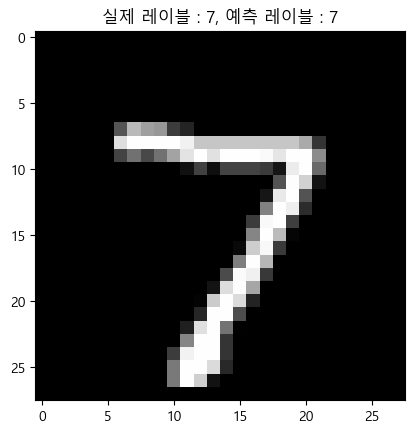

In [81]:
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"실제 레이블 : {sample_label}, 예측 레이블 : {predicted_label}")
plt.show()